# Introduction
In this notebook we will build different models to predict property price.
- Case 1. Train a simple linear regression model to predict property price using only area_m2.
- Case2. Train a multiple linear regression model to predict price using latitude and longitude
- Case 3. Train a simple linear regression model to predict price using state
- Case 4. Train a Ridge regression model using every other feature to predict property price 

# 1). Import necessary libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge 
from sklearn.impute import SimpleImputer 
from category_encoders import OneHotEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import mean_absolute_error
from sklearn.utils.validation import check_is_fitted

# 2). Load data

In [31]:
df=pd.read_csv("/workspaces/Exploring_the_Brazi_-Real_Estate_Market_and_Building_a_model_to_predict_property_prices-/notebooks/brasil-real-estate-clean.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22844 entries, 0 to 22843
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  22844 non-null  str    
 1   state          22844 non-null  str    
 2   region         22844 non-null  str    
 3   lat            22844 non-null  float64
 4   lon            22844 non-null  float64
 5   area_m2        22844 non-null  int64  
 6   price_usd      22844 non-null  float64
dtypes: float64(3), int64(1), str(3)
memory usage: 1.2 MB


# 3). Modelling

## a). Case 1 (Area_m2 and price_usd)

In [33]:
# Feature-target split
features_1=["area_m2"]
X1_train=df[features_1]
X1_train.shape
X1_train.head()
target_1="price_usd"
y1_train=df[target_1]
y1_train.head()


0     82844.596
1    169681.706
2     59887.656
3    169681.706
4     92825.872
Name: price_usd, dtype: float64

In [34]:
# Build Model
# Baselining
y1_mean=y1_train.mean()
y1_mean
y1_pred_baseline=[y1_mean]*len(y1_train)
y1_pred_baseline[:5]

[np.float64(157687.25670977062),
 np.float64(157687.25670977062),
 np.float64(157687.25670977062),
 np.float64(157687.25670977062),
 np.float64(157687.25670977062)]

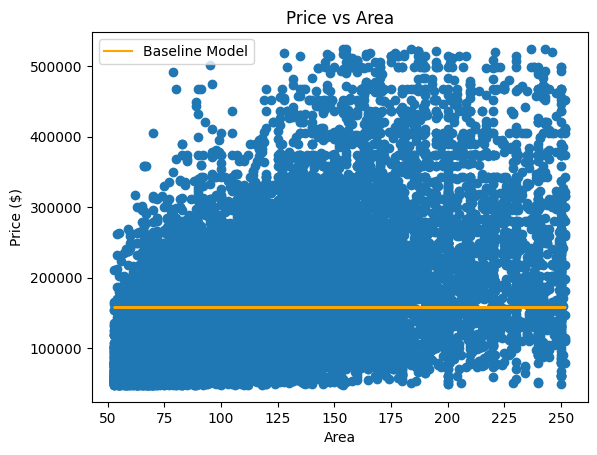

In [35]:
plt.plot(X1_train.values, y1_pred_baseline, color="orange", label="Baseline Model")
plt.scatter(x=X1_train, y=y1_train)
plt.title("Price vs Area")
plt.xlabel("Area")
plt.ylabel("Price ($)")
plt.legend();

In [36]:
mae_baseline=mean_absolute_error(y1_train, y1_pred_baseline)
mae_baseline
print(f"The mean apartment price is: {y1_mean}")
print(f"The baseline mean absolute error is: {mae_baseline}")
# This means that if our baseline model predicts 157,687 as apartment prices, the model would be off by 67,760
# Meaning for us to build a reliable model, we need to build a model whose MAE beats 67760


The mean apartment price is: 157687.25670977062
The baseline mean absolute error is: 67760.24902732237


In [43]:
# Iterate (Build, Train, Evaluate)
# Instantiate
model_1=LinearRegression()
# Fit/Train
model_1.fit(X1_train, y1_train)
# Evaluate (Generate predictions)
y1_pred_training=model_1.predict(X1_train)
mae_training=mean_absolute_error(y1_train, y1_pred_training)
print(f"Mean Absolute Error is: {mae_training}") # compared to baseline mae, it is a pretty decent model

Mean Absolute Error is: 55027.26091257363


In [44]:
# Comunicate
# Extract intercept
intercept_1=model_1.intercept_
coefficient_1=model_1.coef_[0]
print(f"Intercept: {intercept_1}")
print(f"Coefficient: {coefficient_1}")
print(f"Property price = {intercept_1} + {coefficient_1} * area_m2")

Intercept: 44733.77633180258
Coefficient: 982.0314751900466
Property price = 44733.77633180258 + 982.0314751900466 * area_m2


Text(0, 0.5, 'Price [$]')

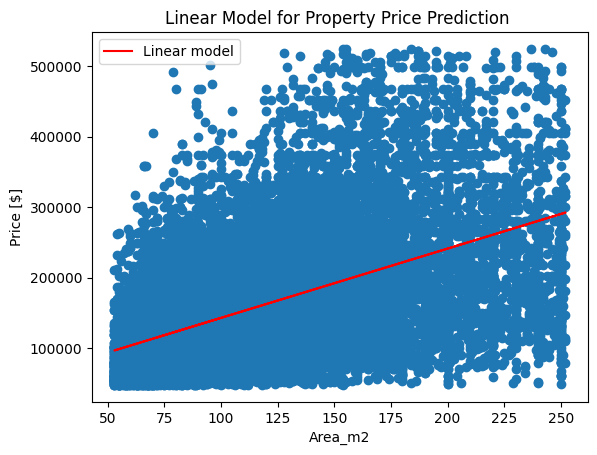

In [45]:
plt.plot(X1_train.values, y1_pred_training, color="red", label="Linear model")
plt.legend()
plt.scatter(y=df["price_usd"], x=df["area_m2"])
plt.title("Linear Model for Property Price Prediction ")
plt.xlabel("Area_m2")
plt.ylabel("Price [$]")

## b) Case 2. (Lat and lon vs Price)

In [46]:
# Split Data to features and target
features_2=["lat", "lon"]
X2_train=df[features_2]
target_2="price_usd"
y2_train=df[target_2]

In [47]:
# Build Model

# Instantiate imputer
# imputer=SimpleImputer()
# Fit/Train imputer
# imputer.fit(X2_train)
# Transform
# XT2_train=imputer.transform(X2_train)

# Create pipeline
model_2=make_pipeline(
    SimpleImputer(),
    LinearRegression()
)
# Train model
model_2.fit(X2_train, y2_train)

# Evaluate
y2_predict=model_2.predict(X2_train)
mae_y2=mean_absolute_error(y2_train, y2_predict)
print(f"MAE training is: {mae_y2}")
print("The model performs just a little better than the baseline model. This suggests that latitude and longitude are not strong predictors of price")

MAE training is: 66567.82674769405
The model performs just a little better than the baseline model. This suggests that latitude and longitude are not strong predictors of price


In [48]:
# Communicate
intercept_2=model_2.named_steps["linearregression"].intercept_
print(intercept_2)
coef_2=model_2.named_steps["linearregression"].coef_
print(coef_2)
print(f"Apartment price= {intercept_2.round()} + {coef_2[0].round()}*lat + {coef_2[1].round()}*lon")


213707.477859254
[1981.80663975  343.97395799]
Apartment price= 213707.0 + 1982.0*lat + 344.0*lon


## c) Case 3. (State vs Price)

In [49]:
# Feature Target split
feature_3=["state"]
target_3="price_usd"
X3_train=df[feature_3]
y3_train=df[target_3]
X3_train.shape

(22844, 1)

In [50]:
# Build model
#  Instantiate transformer
#ohe=OneHotEncoder(use_cat_names=True)
# Fit
#ohe.fit(X3_train)
# Transform
#X3T_train=ohe.transform(X3_train)

model_3=make_pipeline(
    OneHotEncoder(use_cat_names=True),
    LinearRegression()
)
model_3.fit(X3_train, y3_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('onehotencoder', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0",list,['state']
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,1
,cols,['state']
,use_cat_names,True
,verbose,0
,drop_invariant,False


In [51]:
y3_pred=model_3.predict(X3_train)
mae_y3_pred=mean_absolute_error(y3_train, y3_pred)
print(f"Baseline MAE: {mae_baseline}")
print(f"Y3 Model MAE {mae_y3_pred}")

Baseline MAE: 67760.24902732237
Y3 Model MAE 64397.04377032563


Intercept: 145628.80358548608
Coefficients: [ 11375.76795146 -47254.14958549 -42434.02168482 -34298.96444209
  -2010.83261652 -74553.29638549   -438.67070925 -54766.10114431
  -9158.33176395 -87737.40158548  34727.75766451   2720.41641452
   3115.70641452  37587.081104    46985.47783764  41190.03472052
   4060.05414424  25718.5883965   22327.28809768  18083.110368
 -18155.32858549  54905.79748541  18540.03644596  11880.96437451
  37589.01708341]
['state_Pernambuco' 'state_Piauí' 'state_Rio Grande do Norte'
 'state_Rio Grande do Sul' 'state_Rio de Janeiro' 'state_Rondônia'
 'state_Santa Catarina' 'state_Sergipe' 'state_São Paulo'
 'state_Tocantins' 'state_Alagoas' 'state_Amapá' 'state_Amazonas'
 'state_Bahia' 'state_Ceará' 'state_Distrito Federal'
 'state_Espírito Santo' 'state_Goiás' 'state_Maranhão' 'state_Mato Grosso'
 'state_Mato Grosso do Sul' 'state_Minas Gerais' 'state_Paraná'
 'state_Paraíba' 'state_Pará']


/tmp/ipykernel_2866/3221751904.py:7: FutureWarning: `get_feature_names` is deprecated in all of sklearn. Use `get_feature_names_out` instead.
  feature_names=model_3.named_steps["onehotencoder"].get_feature_names()


Text(0.5, 1.0, 'Feature importance ')

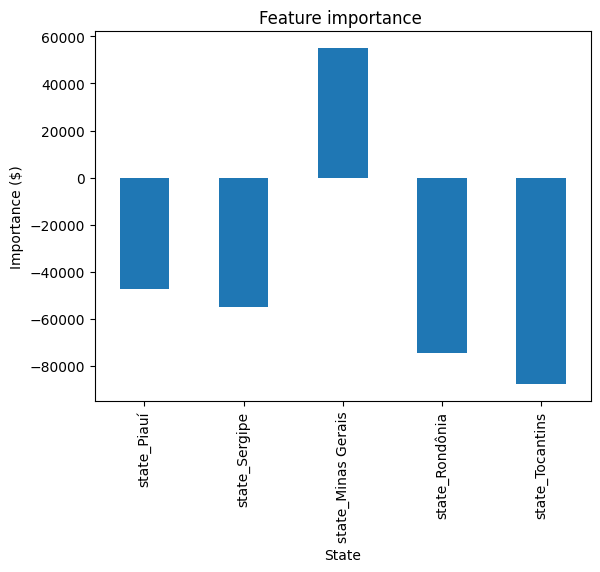

In [52]:
# Communicate
intercept_3=model_3.named_steps["linearregression"].intercept_
coef_3=model_3.named_steps["linearregression"].coef_
print("Intercept:", intercept_3)
print("Coefficients:", coef_3)
# Extract feature names
feature_names=model_3.named_steps["onehotencoder"].get_feature_names()
print(feature_names)
feat_imp=pd.Series(coef_3, index=feature_names)
feat_imp.head()
# Ridge solves the curse of curse of dimensionality and reduces overfitting. Same steps
feat_imp.sort_values(key=abs).tail().plot(kind="bar")
plt.ylabel("Importance ($)")
plt.xlabel("State")
plt.title("Feature importance ")

## c) Case 3 (Modelling with every other feature)

In [19]:
#Prepare Data
# Checklist
# 1. Check for too many nulls --- No Nulls ---
# 2. Check for multicollinearity --- Latitude and longitude are correlated, but together they define a location point
#   Furthermore our goal is prediction, not interpretation
# 3. Check for high/low cardinality features --- None ---
# 4. Check for features that would cause leakage --- None ---

<class 'pandas.DataFrame'>
RangeIndex: 22844 entries, 0 to 22843
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  22844 non-null  str    
 1   state          22844 non-null  str    
 2   region         22844 non-null  str    
 3   lat            22844 non-null  float64
 4   lon            22844 non-null  float64
 5   area_m2        22844 non-null  int64  
 6   price_usd      22844 non-null  float64
dtypes: float64(3), int64(1), str(3)
memory usage: 1.2 MB


<Axes: >

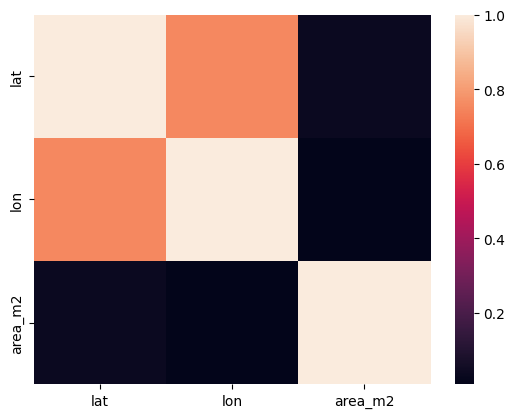

In [53]:
df.info()
df.nunique()
corr_matrix=df.select_dtypes("number").drop(columns="price_usd").corr()
sns.heatmap(corr_matrix)

In [54]:
# Feature-wise splitting
X4_train=df.iloc[:, :-1]
X4_train.head()
X4_train.shape
y4_train=df.iloc[:, -1]
y4_train.shape

(22844,)

In [55]:
# Build model

# Iterate
model_4=make_pipeline(
    OneHotEncoder(use_cat_names=True),
    Ridge()
)
model_4.fit(X4_train, y4_train)
y4_predictions=model_4.predict(X4_train)
mae_y4_train=mean_absolute_error(y4_train, y4_predictions)
mae_y4_train

46065.301989238375

In [56]:
# Communicate
# Create a function that takes in features, turns them into a dataframe, feeds that df to the model and returns predictions
def make_prediction(property_type, state, region, lat, lon, area_m2):
    data={
        "property_type":property_type,
        "state":state,
        "region":region,
        "lat":lat,
        "lon":lon,
        "area_m2":area_m2
    }
    df=pd.DataFrame(data, index=[0])
    prediction=model_4.predict(df).round(2)[0]
    return (f"The predicted property price is: $ {prediction}")

In [57]:
make_prediction("house", "Bahia", "South", -34.02, 35.6, 78 )

'The predicted property price is: $ 1147307.46'